In [ ]:
!pip install spotipy tqdm
!pip install python-dateutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.8/409.8 kB 6.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import os
import numpy as np
import tqdm
import spotipy
from google.colab import files
import zipfile

from spotipy.oauth2 import SpotifyOAuth

In [ ]:
#Spotify API

client_id = 'dbc2c05e26ce46e995da7f6f4fef9d41'
client_secret = 'c82922ab275d4ff8b9ee0e041f9482dd'
redirect_uri = 'http://127.0.0.1:8888/callback'

sp = spotipy.Spotify(auth_manager = SpotifyOAuth(
    client_id = client_id,
    client_secret = client_secret,
    redirect_uri = redirect_uri,
    open_browser = False
))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

data_dir = '/content/drive/MyDrive/Spotify Account Data'
files = os.listdir(data_dir)

print("Found files:", files[:10])  # peek at first 10


Found files: ['Json', "CSV's"]


In [ ]:
os.listdir()

['.config', 'Stream_Hist.csv', 'drive', 'sample_data']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, pandas as pd
from pandas.errors import EmptyDataError, ParserError

base_path = "/content/drive/MyDrive/Spotify Account Data/CSV's"

csv_files = [
    "StreamingHistory_music_0.csv",
    "StreamingHistory_music_1.csv",
    "StreamingHistory_music_2.csv",
    "StreamingHistory_music_3.csv",
    "StreamingHistory_music_4.csv",
    "StreamingHistory_podcast_0.csv",
    "Follow.csv",
    "Identifiers.csv",
    "Identity.csv",
    "Inferences.csv",
    "Marquee.csv",
    "Payments.csv",
    "Playlist1.csv",
    "Playlist2.csv",
    "UserAddress.csv",
    "Userdata.csv",
    "UserPrompts.csv",
    "Wrapped2024.csv",
    "YourLibrary.csv",
    "SearchQueries.csv",
]

dfs = {}
report = {"loaded": [], "empty": [], "not_found": [], "other_error": []}

def safe_read_csv(path):
    # 0-byte or whitespace-only files -> Empty
    try:
        size = os.path.getsize(path)
        if size == 0:
            return None, "empty (0 bytes)"
    except FileNotFoundError:
        return None, "not_found"

    # Try with common options; handle BOM and weird lines gracefully
    try:
        df = pd.read_csv(path, encoding="utf-8-sig", on_bad_lines="skip")
        if df.shape[1] == 0:
            return None, "empty (no columns after parse)"
        return df, None
    except EmptyDataError:
        return None, "empty (pandas EmptyDataError)"
    except ParserError as e:
        # Sometimes a CSV was actually saved as JSON by mistake; try a fallback
        try:
            df_json = pd.read_json(path, lines=False)
            if isinstance(df_json, pd.DataFrame) and df_json.shape[1] > 0:
                return df_json, "parsed as JSON (fallback)"
            return None, f"parser_error: {e}"
        except Exception as e2:
            return None, f"parser_error: {e}; json_fallback_error: {e2}"
    except Exception as e:
        return None, f"other_error: {e}"

for fname in csv_files:
    path = os.path.join(base_path, fname)
    if not os.path.exists(path):
        report["not_found"].append(fname)
        print(f"⚠️ Not found: {fname}")
        continue

    df, err = safe_read_csv(path)
    if df is not None:
        key = fname[:-4]  # strip .csv
        dfs[key] = df
        tag = f" ({err})" if err else ""
        print(f"✅ Loaded {fname} into dfs['{key}'] with {len(df)} rows{tag}")
        report["loaded"].append(fname)
    else:
        if err and err.startswith("empty"):
            print(f"🟨 Empty file: {fname} — {err}")
            report["empty"].append(fname)
        else:
            print(f"🛑 Could not load {fname} — {err}")
            report["other_error"].append((fname, err))

print("\nSummary:")
print(" Loaded:", len(report["loaded"]))
print(" Empty:", len(report["empty"]), report["empty"])
print(" Not found:", len(report["not_found"]), report["not_found"])
print(" Other errors:", len(report["other_error"]), report["other_error"])



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded StreamingHistory_music_0.csv into dfs['StreamingHistory_music_0'] with 10000 rows
✅ Loaded StreamingHistory_music_1.csv into dfs['StreamingHistory_music_1'] with 10000 rows
✅ Loaded StreamingHistory_music_2.csv into dfs['StreamingHistory_music_2'] with 10000 rows
✅ Loaded StreamingHistory_music_3.csv into dfs['StreamingHistory_music_3'] with 10000 rows
✅ Loaded StreamingHistory_music_4.csv into dfs['StreamingHistory_music_4'] with 3663 rows
✅ Loaded StreamingHistory_podcast_0.csv into dfs['StreamingHistory_podcast_0'] with 59 rows
✅ Loaded Follow.csv into dfs['Follow'] with 1 rows
✅ Loaded Identifiers.csv into dfs['Identifiers'] with 1 rows
✅ Loaded Identity.csv into dfs['Identity'] with 1 rows
✅ Loaded Inferences.csv into dfs['Inferences'] with 1 rows
✅ Loaded Marquee.csv into dfs['Marquee'] with 1543 rows
✅ Loaded Payments.csv into dfs['Payments'] 

In [ ]:
dfs['StreamingHistory_music_0']

,end_time,artist_name,track_name,ms_played,minutes_played
0,2024-09-10 00:01:00,Autumn!,All My Duffles Goyard!,179154,2.985900
1,2024-09-10 00:04:00,Babyface Ray,Donda Bag,188250,3.137500
2,2024-09-10 00:06:00,Summrs,Wakeup,133709,2.228483
3,2024-09-10 00:09:00,LUCKI,OUT OF LVE,145133,2.418883
4,2024-09-10 00:12:00,Lil Yachty,TESLA,164742,2.745700
...,...,...,...,...,...
9995,2024-12-07 23:51:00,Lil Tecca,HOMEBODY,119857,1.997617
9996,2024-12-07 23:54:00,Eem Triplin,NEW JACK CITY,122912,2.048533
9997,2024-12-07 23:55:00,Draft Day,UPPING MY RANK,113999,1.899983
9998,2024-12-08 00:10:00,Highway,I Used To,142820,2.380333


In [ ]:
hist1 = dfs['StreamingHistory_music_1']

In [ ]:
hist2 = dfs['StreamingHistory_music_2']

In [ ]:
hist3 = dfs['StreamingHistory_music_3']

In [ ]:
hist4 = dfs['StreamingHistory_music_4']

In [ ]:
len(hist1)

10000

In [ ]:
Stream_Hist = pd.concat([hist1, hist2, hist3, hist4], ignore_index = True)
Stream_Hist

,end_time,artist_name,track_name,ms_played,minutes_played
0,2024-12-08 00:15:00,Destroy Lonely,BERGDORF,145777,2.429617
1,2024-12-08 00:18:00,PARTYNEXTDOOR,Over Here (feat. Drake),177827,2.963783
2,2024-12-08 00:20:00,Fimiguerrero,Vogue,94809,1.580150
3,2024-12-08 00:21:00,BAK Jay,VIP,107571,1.792850
4,2024-12-08 00:23:00,Loe Shimmy,For Me,104886,1.748100
...,...,...,...,...,...
33658,2025-09-10 21:42:00,ScHoolboy Q,Lost Times (feat. Jozzy),173230,2.887167
33659,2025-09-10 21:45:00,Glokk40Spaz,Die With Regret,163474,2.724567
33660,2025-09-10 21:48:00,Aaron May,Closed Hands,179262,2.987700
33661,2025-09-10 21:50:00,Don Toliver,Tiramisu,138947,2.315783


In [ ]:
Stream_Hist.columns

Index(['end_time', 'artist_name', 'track_name', 'ms_played', 'minutes_played'], dtype='object')

In [ ]:
Stream_Hist

,end_time,artist_name,track_name,ms_played,minutes_played
0,2024-12-08 00:15:00,Destroy Lonely,BERGDORF,145777,2.429617
1,2024-12-08 00:18:00,PARTYNEXTDOOR,Over Here (feat. Drake),177827,2.963783
2,2024-12-08 00:20:00,Fimiguerrero,Vogue,94809,1.580150
3,2024-12-08 00:21:00,BAK Jay,VIP,107571,1.792850
4,2024-12-08 00:23:00,Loe Shimmy,For Me,104886,1.748100
...,...,...,...,...,...
33658,2025-09-10 21:42:00,ScHoolboy Q,Lost Times (feat. Jozzy),173230,2.887167
33659,2025-09-10 21:45:00,Glokk40Spaz,Die With Regret,163474,2.724567
33660,2025-09-10 21:48:00,Aaron May,Closed Hands,179262,2.987700
33661,2025-09-10 21:50:00,Don Toliver,Tiramisu,138947,2.315783


In [ ]:
Stream_Hist.to_csv("Stream_Hist.csv", index=False)

In [ ]:
Stream_Hist.head()

,end_time,artist_name,track_name,ms_played,minutes_played
0,2024-12-08 00:15:00,Destroy Lonely,BERGDORF,145777,2.429617
1,2024-12-08 00:18:00,PARTYNEXTDOOR,Over Here (feat. Drake),177827,2.963783
2,2024-12-08 00:20:00,Fimiguerrero,Vogue,94809,1.580150
3,2024-12-08 00:21:00,BAK Jay,VIP,107571,1.792850
4,2024-12-08 00:23:00,Loe Shimmy,For Me,104886,1.748100


In [ ]:
Stream_Hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33663 entries, 0 to 33662
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   end_time        33663 non-null  object 
 1   artist_name     33663 non-null  object 
 2   track_name      33663 non-null  object 
 3   ms_played       33663 non-null  int64  
 4   minutes_played  33663 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 1.3+ MB


In [ ]:
Stream_Hist['end_time'] = pd.to_datetime(Stream_Hist['end_time'])

In [ ]:
Stream_Hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33663 entries, 0 to 33662
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   end_time        33663 non-null  datetime64[ns]
 1   artist_name     33663 non-null  object        
 2   track_name      33663 non-null  object        
 3   ms_played       33663 non-null  int64         
 4   minutes_played  33663 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 1.3+ MB


In [ ]:
Stream_Hist['date'] = Stream_Hist['end_time'].dt.date
Stream_Hist['day_of_week'] = Stream_Hist['end_time'].dt.day_name()
Stream_Hist['hour'] = Stream_Hist['end_time'].dt.hour
Stream_Hist['month'] = Stream_Hist['end_time'].dt.month

In [ ]:
Stream_Hist

,end_time,artist_name,track_name,ms_played,minutes_played,date,day_of_week,hour,month,hour_label
0,2024-12-08 00:15:00,Destroy Lonely,BERGDORF,145777,2.429617,2024-12-08,Sunday,0,12,0:00
1,2024-12-08 00:18:00,PARTYNEXTDOOR,Over Here (feat. Drake),177827,2.963783,2024-12-08,Sunday,0,12,0:00
2,2024-12-08 00:20:00,Fimiguerrero,Vogue,94809,1.580150,2024-12-08,Sunday,0,12,0:00
3,2024-12-08 00:21:00,BAK Jay,VIP,107571,1.792850,2024-12-08,Sunday,0,12,0:00
4,2024-12-08 00:23:00,Loe Shimmy,For Me,104886,1.748100,2024-12-08,Sunday,0,12,0:00
...,...,...,...,...,...,...,...,...,...,...
33658,2025-09-10 21:42:00,ScHoolboy Q,Lost Times (feat. Jozzy),173230,2.887167,2025-09-10,Wednesday,21,9,21:00
33659,2025-09-10 21:45:00,Glokk40Spaz,Die With Regret,163474,2.724567,2025-09-10,Wednesday,21,9,21:00
33660,2025-09-10 21:48:00,Aaron May,Closed Hands,179262,2.987700,2025-09-10,Wednesday,21,9,21:00
33661,2025-09-10 21:50:00,Don Toliver,Tiramisu,138947,2.315783,2025-09-10,Wednesday,21,9,21:00


In [ ]:
hourly_listening = Stream_Hist.groupby('hour')['minutes_played'].sum().reset_index()
hourly_listening.sort_values('minutes_played', ascending = False)

,hour,minutes_played
19,19,7004.699767
18,18,6923.691083
17,17,6767.603250
20,20,6263.196183
21,21,6035.818483
16,16,5467.443117
22,22,4774.191717
3,3,3487.221717
15,15,3462.809033
4,4,3405.098233


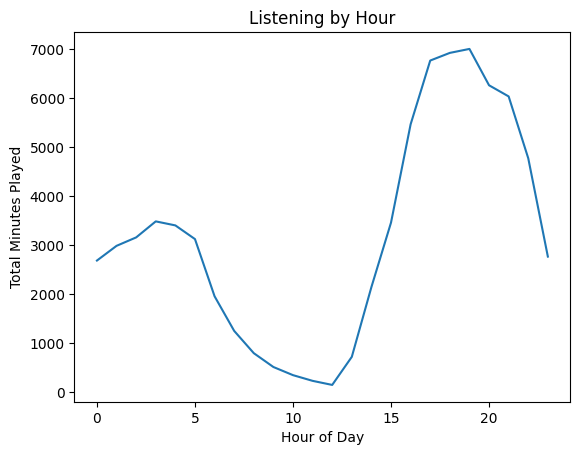

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(hourly_listening['hour'], hourly_listening['minutes_played'])
plt.xlabel('Hour of Day')
plt.ylabel('Total Minutes Played')
plt.title('Listening by Hour')
plt.show()

In [ ]:
top_artists = Stream_Hist.groupby('artist_name')['minutes_played'].sum().reset_index()

top_artists.sort_values('minutes_played', ascending=False).head(20)

,artist_name,minutes_played
361,Drake,3769.548033
520,J. Cole,2146.358000
622,Kendrick Lamar,1609.568250
191,Brent Faiyaz,1436.093000
905,Playboi Carti,1188.658867
878,PARTYNEXTDOOR,1108.798667
661,LUCKI,1070.471583
709,Loe Shimmy,1025.009583
438,Freddie Gibbs,1006.697383
139,Benji Blue Bills,1006.607950


In [ ]:
top_tracks = Stream_Hist.groupby(['artist_name', 'track_name'])['minutes_played'].sum().reset_index()

top_tracks.sort_values('minutes_played', ascending=False).head(10)

,artist_name,track_name,minutes_played
6548,WavyNavyBaby1,Trap Smart,260.923383
4545,N.E.R.D,Bobby James,219.408167
4606,Nas,Still Dreaming,214.023900
5704,Snoop Dogg,Let's Get Blown,200.459650
1972,Drake,Say What's Real,190.573100
1871,Drake,Club Paradise,188.618250
306,A$AP Rocky,PMW (All I Really Need) (feat. ScHoolboy Q),186.939900
2978,Jhené Aiko,The Pressure,178.762433
93,1900Rugrat,Glass Bowls,164.288533
1476,D. Savage,Palm Of My Hand,164.252583


In [ ]:
monthly_listening = Stream_Hist.groupby('month')['minutes_played'].sum().reset_index()

monthly_listening.sort_values('month')

,month,minutes_played
0,1,8981.456467
1,2,8974.079067
2,3,8361.403333
3,4,9838.212333
4,5,8409.751567
5,6,7747.021417
6,7,8293.052650
7,8,7710.646117
8,9,2080.076733
9,12,6066.657883


In [ ]:
Stream_Hist.to_csv('clean_spotify_data.csv', index=False)

In [ ]:
features = Stream_Hist[['minutes_played', 'hour']]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
Stream_Hist['cluster'] = kmeans.fit_predict(scaled_features)

In [ ]:
Stream_Hist['cluster'].value_counts()

,count
cluster,
2,14828
1,10695
0,8140


In [ ]:
cluster_summary = Stream_Hist.groupby('cluster')[['minutes_played', 'hour']].mean()

cluster_summary

,minutes_played,hour
cluster,,
0,0.796662,18.444717
1,2.147920,3.398223
2,3.170051,18.444092


In [ ]:
def label_cluster(c):
    if c == 0:
        return 'Quick Skips'
    elif c == 1:
        return 'Late Night Listening'
    else:
        return 'Full Listening Sessions'

Stream_Hist['cluster_label'] = Stream_Hist['cluster'].apply(label_cluster)

In [ ]:
Stream_Hist[['cluster', 'cluster_label']].head()

,cluster,cluster_label
0,1,Late Night Listening
1,1,Late Night Listening
2,1,Late Night Listening
3,1,Late Night Listening
4,1,Late Night Listening


In [ ]:
Stream_Hist.head()

,end_time,artist_name,track_name,ms_played,minutes_played,date,day_of_week,hour,month,hour_label,cluster,cluster_label
0,2024-12-08 00:15:00,Destroy Lonely,BERGDORF,145777,2.429617,2024-12-08,Sunday,0,12,0:00,1,Late Night Listening
1,2024-12-08 00:18:00,PARTYNEXTDOOR,Over Here (feat. Drake),177827,2.963783,2024-12-08,Sunday,0,12,0:00,1,Late Night Listening
2,2024-12-08 00:20:00,Fimiguerrero,Vogue,94809,1.580150,2024-12-08,Sunday,0,12,0:00,1,Late Night Listening
3,2024-12-08 00:21:00,BAK Jay,VIP,107571,1.792850,2024-12-08,Sunday,0,12,0:00,1,Late Night Listening
4,2024-12-08 00:23:00,Loe Shimmy,For Me,104886,1.748100,2024-12-08,Sunday,0,12,0:00,1,Late Night Listening


In [ ]:
Stream_Hist.to_csv('spotify_clustered_data.csv', index=False)

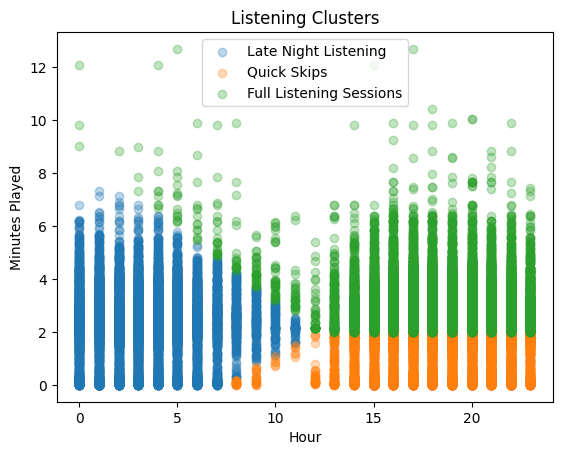

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
for label in Stream_Hist['cluster_label'].unique():
    subset = Stream_Hist[Stream_Hist['cluster_label'] == label]
    plt.scatter(subset['hour'], subset['minutes_played'], label=label, alpha=0.3)

plt.xlabel('Hour')
plt.ylabel('Minutes Played')
plt.title('Listening Clusters')
plt.legend()
plt.show()

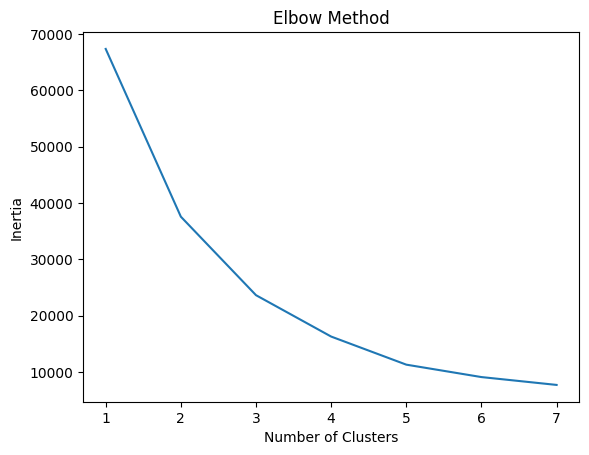

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 8), inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()